<a href="https://colab.research.google.com/github/sreekuttysanthosh/Loan-Default-Risk-Classification/blob/feature%2Fdata-prep-and-eda/notebooks/1_Data_Cleaning_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Default Risk Classification for Banking

## Problem Statement
The objective of this project is to predict whether a loan applicant is likely to default based on financial, demographic, and credit-related information.

Financial institutions face significant risks when approving loans for high-risk customers. Therefore, machine learning techniques can help identify potential defaulters and support better lending decisions.

## Project Objectives
- Perform data cleaning and preprocessing
- Handle missing values and class imbalance
- Conduct exploratory data analysis (EDA)
- Engineer meaningful financial risk features
- Prepare data for machine learning models
- Optimize recall to reduce risky loan approvals
- Use explainable AI techniques such as SHAP for interpretability

## Dataset Information
This project uses a modified version of the Home Credit Default Risk dataset.

Source:
Mendeley Data Repository

Original Dataset:
Kaggle Home Credit Default Risk Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import pandas as pd

df = pd.read_csv("/Users/laniyamohan/Desktop/PREDICTIVE/project3/Loan-Default-Risk-Classification/data/application_train new.csv")

print(df.shape)
df.head()

/var/folders/dg/tcn3pd_94gj24bx7z_1xd6d00000gn/T/ipykernel_4460/792881748.py:3: DtypeWarning: Columns (0: NUM_INSTALMENT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/laniyamohan/Desktop/PREDICTIVE/project3/Loan-Default-Risk-Classification/data/application_train new.csv")


(307511, 123)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Stage 2 — Data Understanding

In [12]:
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Distribution:\n")
print(df['TARGET'].value_counts())

print("\nTarget Percentage:\n")
print(df['TARGET'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 123 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(1), str(16)
memory usage: 288.6+ MB
None

Missing Values:

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 123, dtype: int64

Target Distribution:

TARGET
0    282686
1     24825
Name: count, dtype: int64

Target Percentage:

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


# --- STAGE 3: DATA CLEANING ---

In [13]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False).head(20)

COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MEDI              208642
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

In [14]:
threshold = len(df) * 0.5

df = df.dropna(thresh=threshold, axis=1)

print("New Shape:", df.shape)

New Shape: (307511, 82)


Columns with excessive missing values were removed to improve data quality and reduce noise.

In [15]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining Missing Values:", df.isnull().sum().sum())

/var/folders/dg/tcn3pd_94gj24bx7z_1xd6d00000gn/T/ipykernel_4460/17889478.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Remaining Missing Values: 0


# Stage 4 — EDA Visualizations

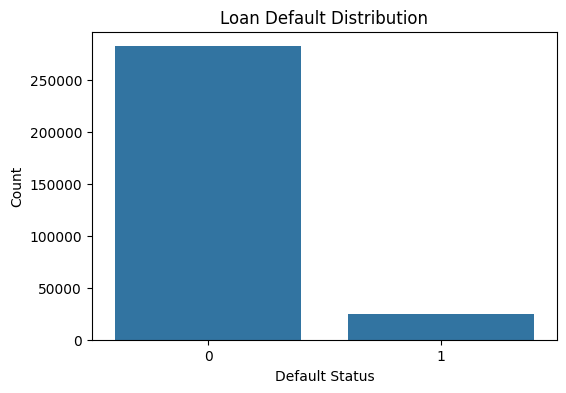

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Count")

plt.show()

income distribution

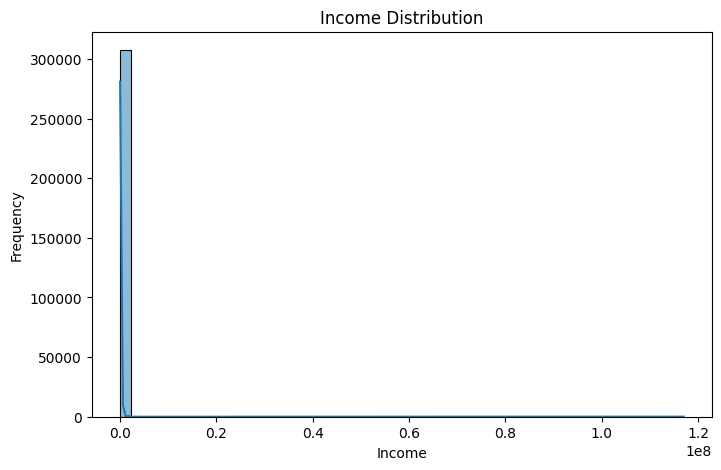

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['AMT_INCOME_TOTAL'], bins=50, kde=True)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

income vs default risk properly using a boxplot.

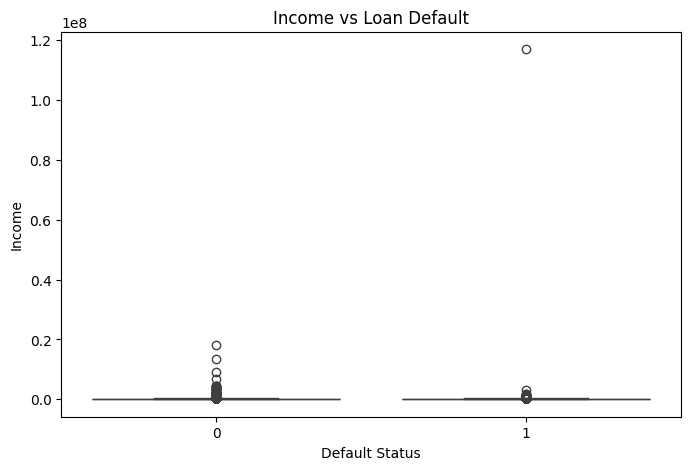

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)

plt.title("Income vs Loan Default")
plt.xlabel("Default Status")
plt.ylabel("Income")

plt.show()

The income feature contains significant outliers and a highly skewed distribution. Most applicants fall within a lower income range, while a few extreme values stretch the distribution.

Credit Score vs Default

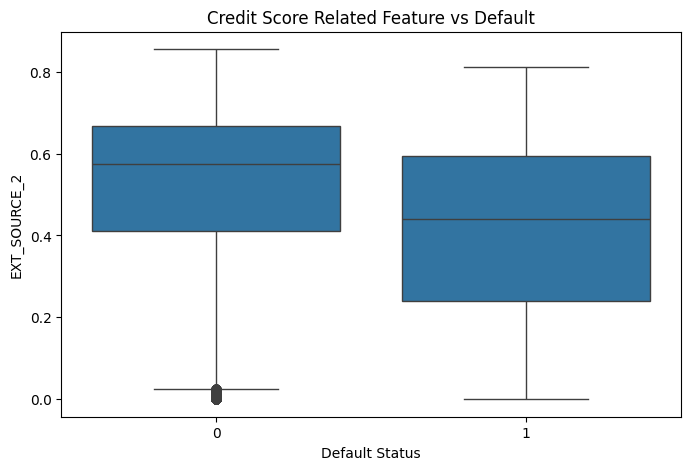

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='EXT_SOURCE_2', data=df)

plt.title("Credit Score Related Feature vs Default")
plt.xlabel("Default Status")
plt.ylabel("EXT_SOURCE_2")

plt.show()

Applicants with lower EXT_SOURCE_2 values show a higher likelihood of loan default, indicating that external credit-related scores are strong predictors of repayment risk.

Correlation Heatmap

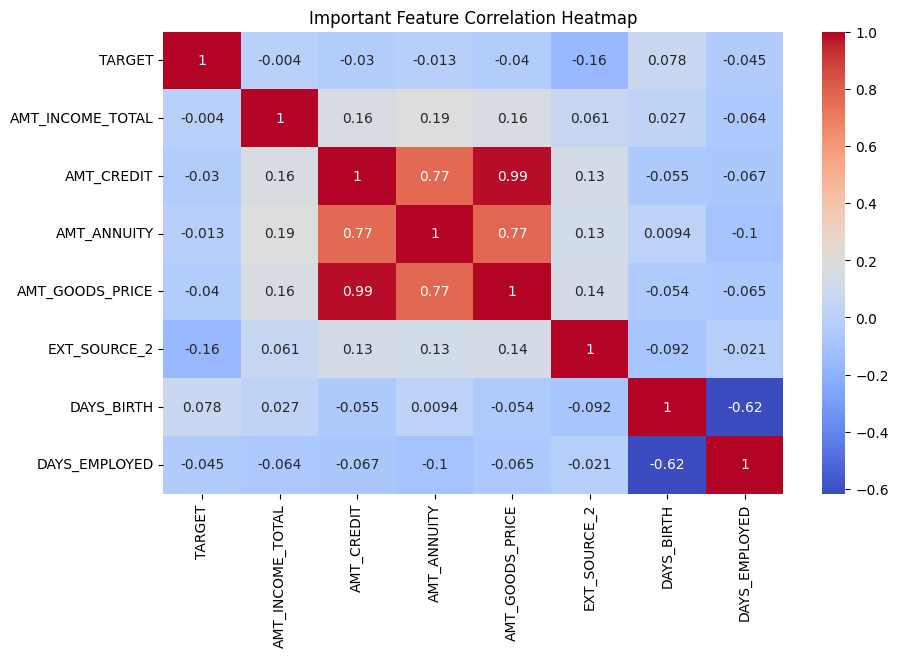

In [20]:
important_features = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_2',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

plt.figure(figsize=(10,6))

corr_matrix = df[important_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Important Feature Correlation Heatmap")

plt.show()

# Stage 5 — Feature Engineering & Selection

In [21]:
df['LOAN_TO_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

df['LOAN_TO_INCOME_RATIO'].head()

0    2.007889
1    4.790750
2    2.000000
3    2.316167
4    4.222222
Name: LOAN_TO_INCOME_RATIO, dtype: float64

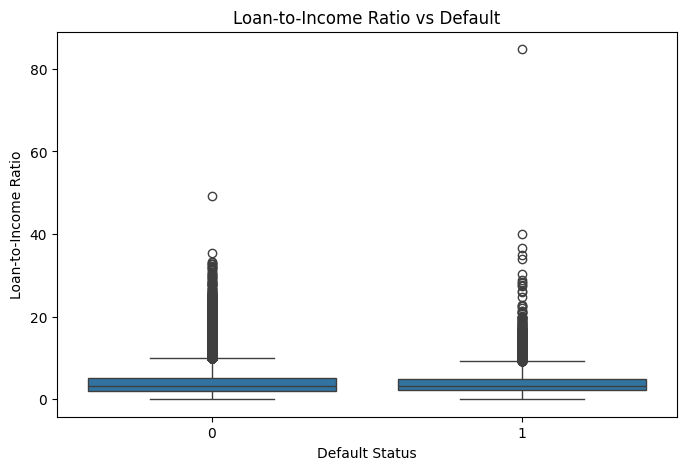

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='TARGET', y='LOAN_TO_INCOME_RATIO', data=df)

plt.title("Loan-to-Income Ratio vs Default")
plt.xlabel("Default Status")
plt.ylabel("Loan-to-Income Ratio")

plt.show()

Do defaulters generally have higher loan burden compared to income?

In [22]:
selected_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'EXT_SOURCE_2',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'LOAN_TO_INCOME_RATIO'
]

X = df[selected_features]

y = df['TARGET']

print(X.shape)
print(y.shape)

(307511, 8)
(307511,)


# train-test split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (246008, 8)
Testing Shape: (61503, 8)


In [24]:
train_df = X_train.copy()
train_df['TARGET'] = y_train

test_df = X_test.copy()
test_df['TARGET'] = y_test

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Train and test CSV files created successfully.")

Train and test CSV files created successfully.


Apply SMOTE to training set only 

In [27]:
from imblearn.over_sampling import SMOTE

In [28]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE train size : {X_train_sm.shape}")
print(f"After SMOTE class balance:\n{pd.Series(y_train_sm).value_counts()}")


After SMOTE train size : (452296, 8)
After SMOTE class balance:
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print("Scaling done ✓")

Scaling done ✓


## Logistic Regression Model Training

In this step, the Logistic Regression model was trained using the scaled training dataset. Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems such as loan default prediction.

The parameter `class_weight='balanced'` was used to handle class imbalance by assigning higher importance to the minority class. Feature scaling was applied before training to improve model performance and convergence.

The model was trained using the SMOTE-balanced training data (`X_train_sm`, `y_train_sm`) and predictions were generated on the test dataset. Probability scores were also calculated using `predict_proba()` for further evaluation metrics such as ROC-AUC.

Finally, the classification report was generated to evaluate model performance using metrics including:
- Precision
- Recall
- F1-score
- Accuracy

This helps in understanding how effectively the model predicts loan defaults and non-default cases.


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.1,
    solver='lbfgs',
    random_state=42
)

lr.fit(X_train_sc, y_train_sm)

y_pred_lr = lr.predict(X_test_sc)

y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

print("Logistic Regression trained ✓")

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['No Default', 'Default']
))

Logistic Regression trained ✓
              precision    recall  f1-score   support

  No Default       0.95      0.67      0.78     56538
     Default       0.14      0.59      0.22      4965

    accuracy                           0.66     61503
   macro avg       0.54      0.63      0.50     61503
weighted avg       0.88      0.66      0.74     61503



```markdown id="l7v2mh"
## Random Forest Model Training

The Random Forest Classifier was trained using the SMOTE-balanced dataset to improve prediction performance on imbalanced classes. Random Forest is an ensemble learning algorithm that combines multiple decision trees to produce more accurate and stable predictions.

The model was configured with balanced class weights and optimized hyperparameters such as maximum depth and minimum samples per leaf to reduce overfitting. After training, predictions and probability scores were generated on the test dataset.

Finally, the classification report was used to evaluate the model’s performance based on precision, recall, F1-score, and accuracy.
```


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained ✓")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['No Default', 'Default']
))

Random Forest trained ✓
              precision    recall  f1-score   support

  No Default       0.95      0.67      0.79     56538
     Default       0.14      0.59      0.22      4965

    accuracy                           0.66     61503
   macro avg       0.54      0.63      0.50     61503
weighted avg       0.88      0.66      0.74     61503



# ── Compute scale_pos_weight to handle class imbalance natively ──


In [39]:
import lightgbm as lgb
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}")

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    min_child_samples=50,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_jobs=-1,
    random_state=42
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

y_pred_lgbm  = lgbm.predict(X_test)
y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("\nLightGBM trained ✓")
print(classification_report(y_test, y_pred_lgbm, target_names=['No Default', 'Default']))

scale_pos_weight = 11.39
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007162 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1933
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

LightGBM trained ✓
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Confusion Matrix Visualization

Confusion matrices were generated for all trained machine learning models to evaluate their classification performance. A confusion matrix provides a detailed summary of prediction results by comparing actual and predicted class labels.

The matrix displays:
- True Positives (correctly predicted defaults)
- True Negatives (correctly predicted non-defaults)
- False Positives
- False Negatives

This visualization helps in understanding model effectiveness, identifying classification errors, and comparing the performance of different models such as Logistic Regression, Random Forest, and LightGBM.

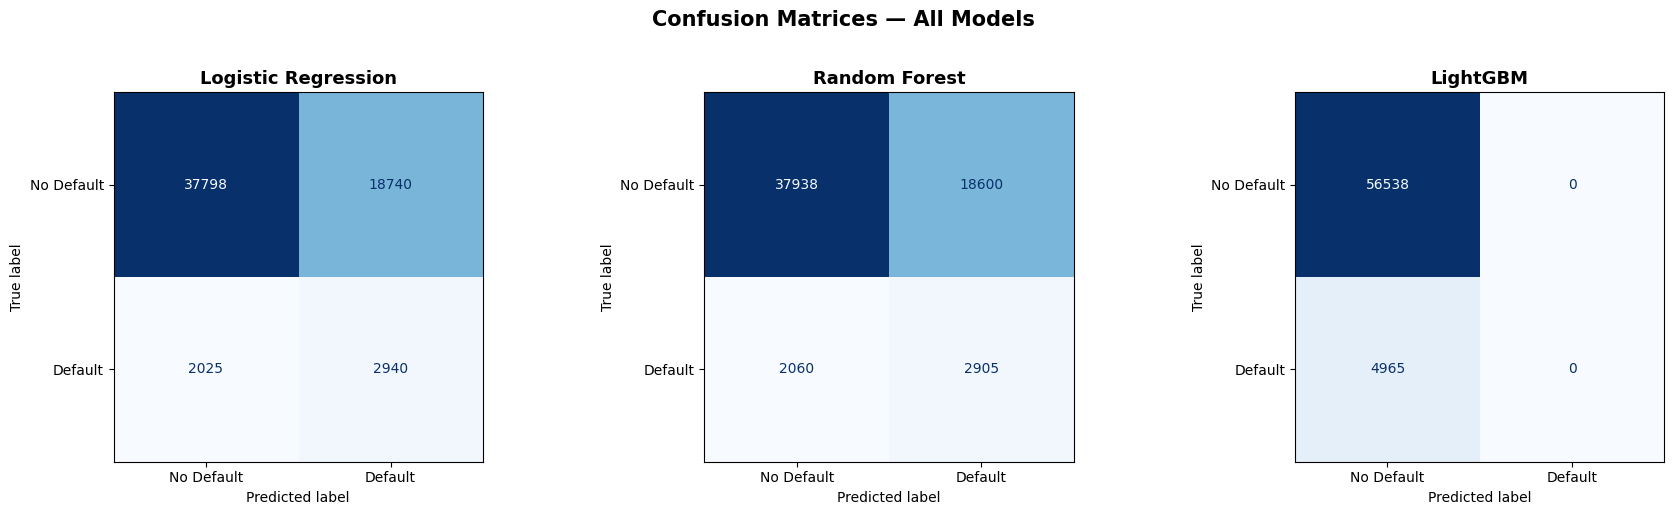

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',        y_pred_rf),
    ('LightGBM',             y_pred_lgbm)
]

for ax, (name, y_pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()